In [1]:
# Multi-task Dataset: depth + zebra-crossing bbox + 4 keypoints + traffic-light class.

# Dataloader menyediakan target MENTAH (belum Pythagoras -- itu nanti di model):
#     image        : [3, H, W]   RGB ternormalisasi
#     depth        : [1, H, W]   depth dalam METER (0 = invalid)
#     depth_mask   : [1, H, W]   1 = valid, 0 = invalid
#     bbox         : [4]         cx,cy,w,h ternormalisasi (0..1)
#     has_object   : [1]         1 kalau ada zebra cross, else 0
#     keypoints    : [4, 3]      (x_norm, y_norm, visible) -> end0,end1,start2,start3
#     light        : []          0=No-Light, 1=Green, 2=Red
#     height_cm    : [1]         tinggi kamera dari nama file (cm) -> untuk Pythagoras di model
#     frame_id     : str
import os, re, json, glob
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
DEPTH_SCALE   = 1.0 / 1000.0     # uint16 mm -> meter (RealSense). Set 1.0 kalau sudah meter.
INVALID_DEPTH = 0                # nilai "tidak terukur"
DEPTH_MAX     = 15.0            # meter. Nilai >= ini (mis. 65535) dianggap saturated -> di-mask
IMG_SIZE      = (512, 256)       # (H, W) input model
LIGHT_MAP     = {"No-Light": 0, "Green": 1, "Red": 2}

IMG_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMG_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def parse_frame_id(name):
    """'20260715_085238_120_000003_png.rf.XXXX.png' -> '20260715_085238_120_000003'"""
    base = os.path.basename(name)
    m = re.match(r"(\d{8}_\d{6}_\d+_\d+)", base)
    return m.group(1) if m else None


def parse_height_cm(frame_id):
    """Field ke-3 dari frame id = tinggi kamera (cm): 20260715_085238_[120]_000003"""
    parts = frame_id.split("_")
    if len(parts) >= 3 and parts[2].isdigit():
        return float(parts[2])
    return float("nan")

In [7]:
class MultiTaskCrossingDataset(Dataset):
    def __init__(self, img_dir, depth_dir, coco_json,
                    img_size=IMG_SIZE, depth_scale=DEPTH_SCALE,
                    depth_max=DEPTH_MAX, augment=False):
        self.img_dir        = img_dir
        self.depth_dir      = depth_dir
        self.img_size       = img_size
        self.depth_scale    = depth_scale
        self.augment        = augment
        self.depth_min      = 0.001
        self.depth_max      = depth_max

        with open(coco_json) as f:
            coco = json.load(f)

        self.cats = {c["id"]: c for c in coco["categories"]}
        self.obj_cat_id = next((c["id"] for c in coco["categories"]
                                if "keypoints" in c), 1)

        anns_by_img = {}
        for a in coco["annotations"]:
            anns_by_img.setdefault(a["image_id"], []).append(a)

        self.samples = []
        depth_index = self._index_depth(depth_dir)

        for im in coco["images"]:
            fid = parse_frame_id(im["file_name"])
            if fid is None:
                continue
            img_path = os.path.join(img_dir, im["file_name"])
            if not os.path.exists(img_path):
                img_path = self._resolve_image(im["file_name"])
                if img_path is None:
                    continue
            if fid not in depth_index:
                continue

            tags = im.get("extra", {}).get("user_tags", [])
            self.samples.append({
                "frame_id":   fid,
                "img_path":   img_path,
                "depth_path": depth_index[fid],
                "orig_w":     im["width"],
                "orig_h":     im["height"],
                "anns":       anns_by_img.get(im["id"], []),
                "light":      self._pick_light(tags),
                "height_cm":  parse_height_cm(fid),
            })

    def _index_depth(self, depth_dir):
        idx = {}
        for f in glob.glob(os.path.join(depth_dir, "*.npy")):
            fid = parse_frame_id(f)
            if fid:
                idx[fid] = f
        return idx

    def _resolve_image(self, file_name):
        stem = file_name.split(".rf.")[0]
        for f in glob.glob(os.path.join(self.img_dir, "*.png")):
            b = os.path.basename(f)
            if stem in b or stem in b.replace("_png_rf_", "_png.rf."):
                return f
        return None

    def _pick_light(self, tags):
        for t in tags:
            if t in LIGHT_MAP:
                return LIGHT_MAP[t]
        return 0

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        s = self.samples[i]
        Ht, Wt = self.img_size
        ow, oh = s["orig_w"], s["orig_h"]

        # ---- image ----
        img = Image.open(s["img_path"]).convert("RGB").resize((Wt, Ht), Image.BILINEAR)
        img = torch.from_numpy(np.asarray(img, dtype=np.float32) / 255.0).permute(2, 0, 1)
        
        # ---- depth ---- (nearest resize supaya lubang/invalid tidak terinterpolasi)
        depth = np.load(s["depth_path"]).astype(np.float32)
        depth = np.asarray(
                    Image.fromarray(depth).resize((Wt, Ht), Image.NEAREST),
                    dtype=np.float32
                )
        
        depth = depth * self.depth_scale                       # -> meter
        mask = ((depth >= self.depth_min) & (depth < self.depth_max)).astype(np.float32)
        depth = torch.from_numpy(depth).unsqueeze(0)
        depth_mask = torch.from_numpy(mask).unsqueeze(0)
        
        # ---- deteksi (asumsi maks 1 zebra cross) ----
        bbox = torch.zeros(4, dtype=torch.float32)
        kpts = torch.zeros(4, 3, dtype=torch.float32)
        has_object = torch.zeros(1, dtype=torch.float32)

        obj_anns = [a for a in s["anns"] if a["category_id"] == self.obj_cat_id]
        if obj_anns:
            a = max(obj_anns, key=lambda x: x.get("area", 0))  # ambil yang terbesar
            has_object[0] = 1.0
            x, y, w, h = a["bbox"]
            bbox = torch.tensor([(x + w/2)/ow, (y + h/2)/oh, w/ow, h/oh],
                                dtype=torch.float32)
            kp = a.get("keypoints", [])
            for j in range(min(4, len(kp)//3)):
                kx, ky, v = kp[3*j], kp[3*j+1], kp[3*j+2]
                kpts[j, 0] = kx/ow
                kpts[j, 1] = ky/oh
                kpts[j, 2] = 1.0 if v > 0 else 0.0

        return {
            "image":      img,
            "depth":      depth,
            "depth_mask": depth_mask,
            "bbox":       bbox,
            "has_object": has_object,
            "keypoints":  kpts,
            "light":      torch.tensor(s["light"], dtype=torch.long),
            "height_cm":  torch.tensor([s["height_cm"]], dtype=torch.float32),
            "frame_id":   s["frame_id"],
        }


def collate_fn(batch):
    out = {}
    for k in ["image", "depth", "depth_mask", "bbox",
                "has_object", "keypoints", "light", "height_cm"]:
        out[k] = torch.stack([b[k] for b in batch], dim=0)
    out["frame_id"] = [b["frame_id"] for b in batch]
    return out

In [8]:
ds = MultiTaskCrossingDataset(
        img_dir   = "new_ds/train",
        depth_dir = "new_ds/Depth",
        coco_json = "new_ds/train/_annotations_coco.json",
    )
print("usable samples:", len(ds))

dl = DataLoader(ds, batch_size=10, shuffle=False, collate_fn=collate_fn, num_workers=0)

usable samples: 1000


In [9]:
batch = next(iter(dl))
for k, v in batch.items():
    if torch.is_tensor(v):
        print(f"  {k:12s}: {tuple(v.shape)} {v.dtype}")
    else:
        print(f"  {k:12s}: {v}")
print("has_object:", batch["has_object"].squeeze(1).tolist())
print("light     :", batch["light"].tolist())
print("height_cm :", batch["height_cm"].squeeze(1).tolist())

  image       : (10, 3, 512, 256) torch.float32
  depth       : (10, 1, 512, 256) torch.float32
  depth_mask  : (10, 1, 512, 256) torch.float32
  bbox        : (10, 4) torch.float32
  has_object  : (10, 1) torch.float32
  keypoints   : (10, 4, 3) torch.float32
  light       : (10,) torch.int64
  height_cm   : (10, 1) torch.float32
  frame_id    : ['20260715_092407_120_000006', '20260715_085311_130_000006', '20260715_085311_130_000008', '20260715_085238_120_000008', '20260715_092407_120_000013', '20260715_085311_130_000005', '20260715_091737_150_000008', '20260715_085238_120_000017', '20260715_085238_120_000003', '20260715_092429_120_000009']
has_object: [1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0]
light     : [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
height_cm : [120.0, 130.0, 130.0, 120.0, 120.0, 130.0, 150.0, 120.0, 120.0, 120.0]


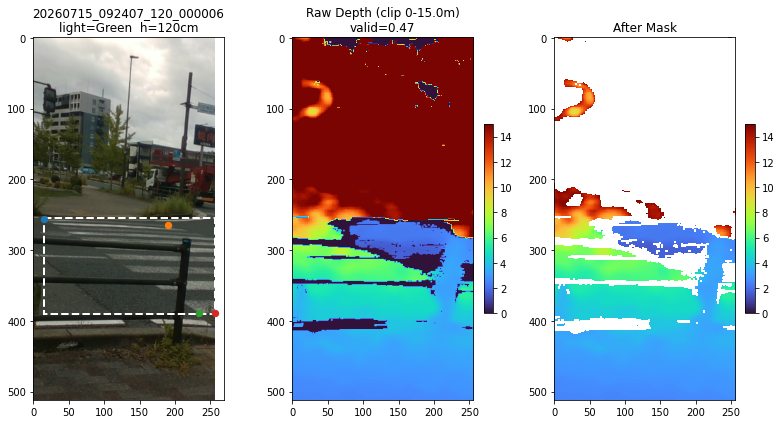

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

LIGHT_NAMES = {0: "No-Light", 1: "Green", 2: "Red"}

def show_item(batch, i=0, vmax=DEPTH_MAX):
    img = batch["image"][i].permute(1, 2, 0).numpy().clip(0, 1)
    H, W = img.shape[:2]
    depth = batch["depth"][i, 0].numpy()
    mask  = batch["depth_mask"][i, 0].numpy()
    depth_masked = np.where(mask > 0, depth, np.nan)

    fig, ax = plt.subplots(1, 3, figsize=(11, 6))

    ax[0].imshow(img)
    if batch["has_object"][i].item() > 0:
        cx, cy, w, h = batch["bbox"][i].tolist()
        ax[0].add_patch(patches.Rectangle(
            ((cx-w/2)*W, (cy-h/2)*H), w*W, h*H,
            fill=False, edgecolor="white", lw=2, ls="--"))
        for j, (kx, ky, v) in enumerate(batch["keypoints"][i].tolist()):
            if v > 0:
                ax[0].scatter(kx*W, ky*H, s=40)
    ax[0].set_title(f"{batch['frame_id'][i]}\n"
                    f"light={LIGHT_NAMES[int(batch['light'][i])]}  "
                    f"h={float(batch['height_cm'][i]):.0f}cm")

    # kedua panel depth pakai vmin/vmax SAMA supaya warnanya bisa dibandingkan
    im0 = ax[1].imshow(depth, cmap="turbo", vmin=0, vmax=vmax)
    ax[1].set_title(f"Raw Depth (clip 0-{vmax}m)\nvalid={mask.mean():.2f}")
    fig.colorbar(im0, ax=ax[1], fraction=0.046)

    im1 = ax[2].imshow(depth_masked, cmap="turbo", vmin=0, vmax=vmax)
    ax[2].set_title("After Mask")
    fig.colorbar(im1, ax=ax[2], fraction=0.046)

    plt.tight_layout()
    plt.show()

show_item(batch, 0)

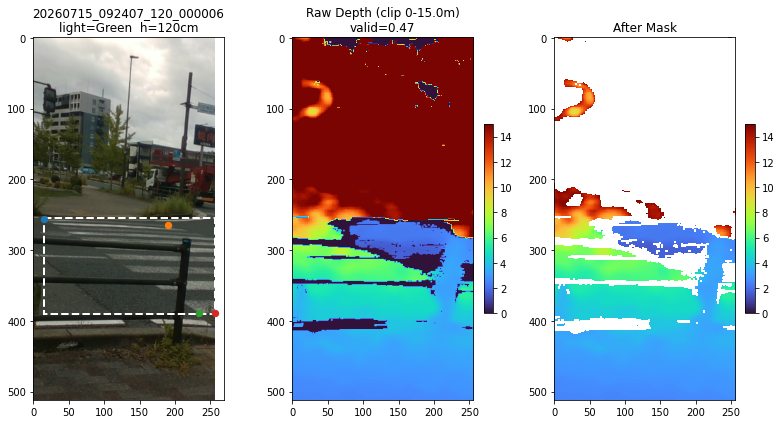

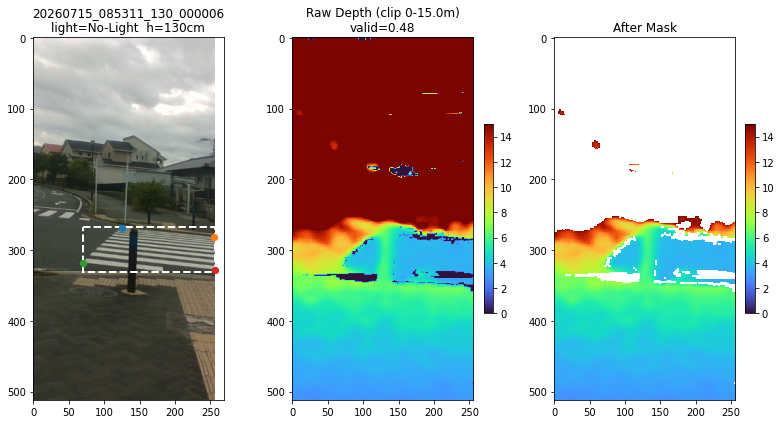

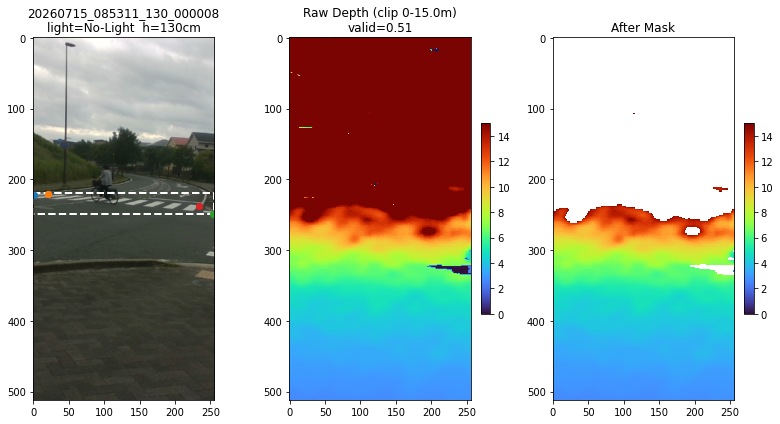

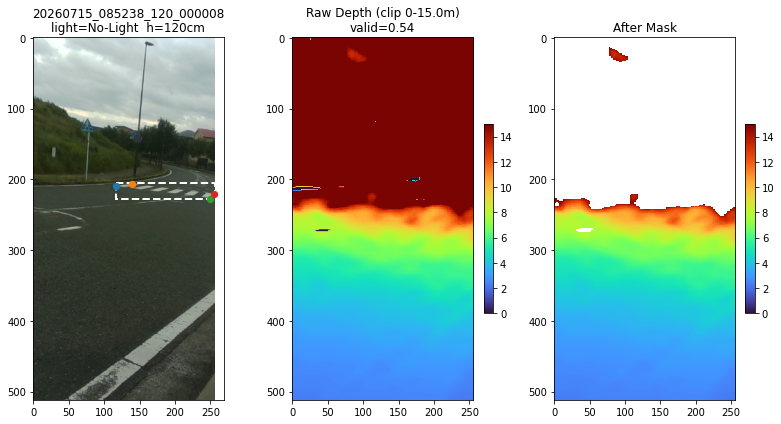

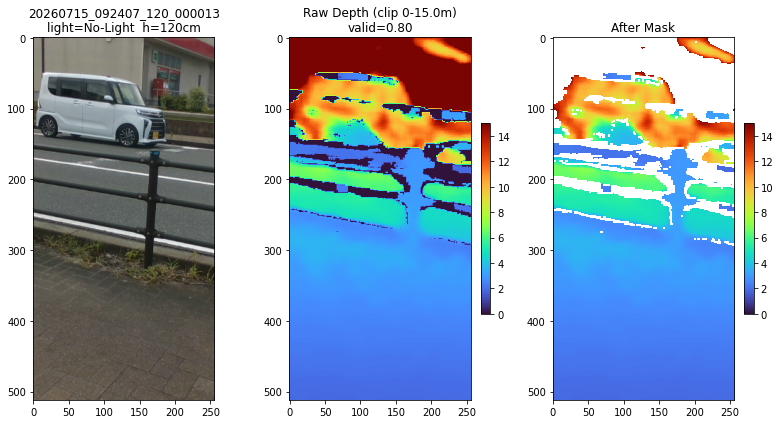

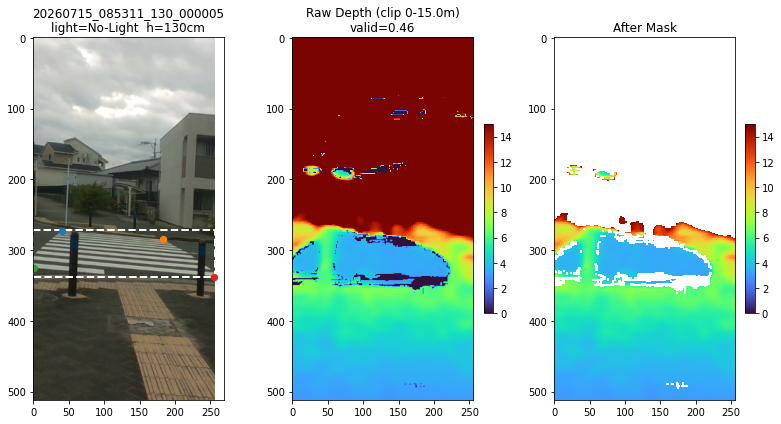

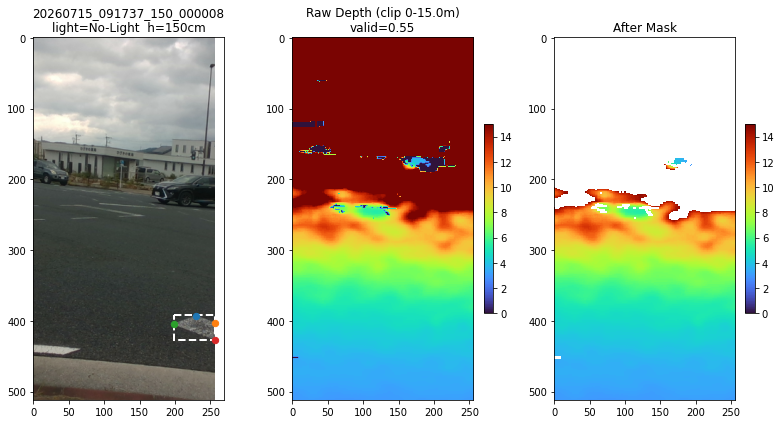

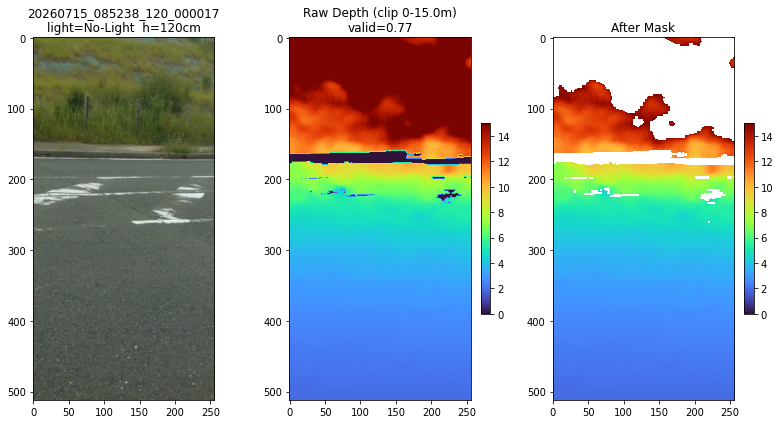

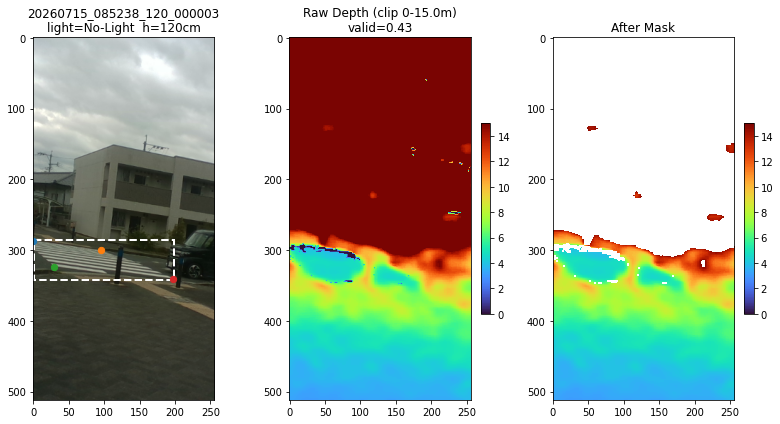

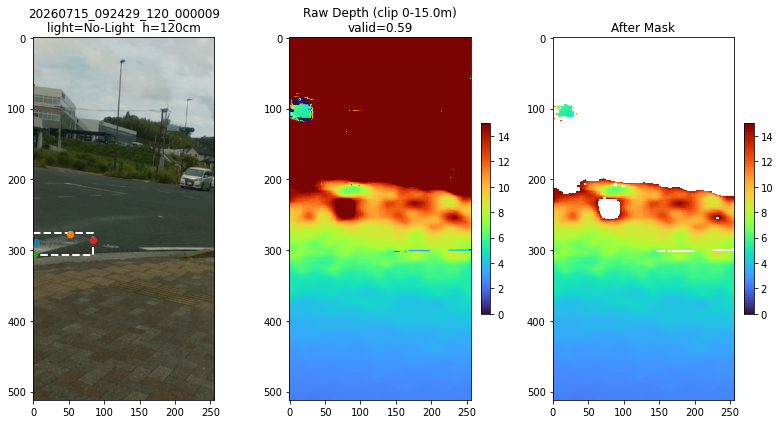

In [11]:
for i in range(batch["image"].shape[0]):
    show_item(batch, i)

## Depth Fillhole

In [14]:
import numpy as np, cv2, glob
from scipy import ndimage
from PIL import Image
import matplotlib.pyplot as plt

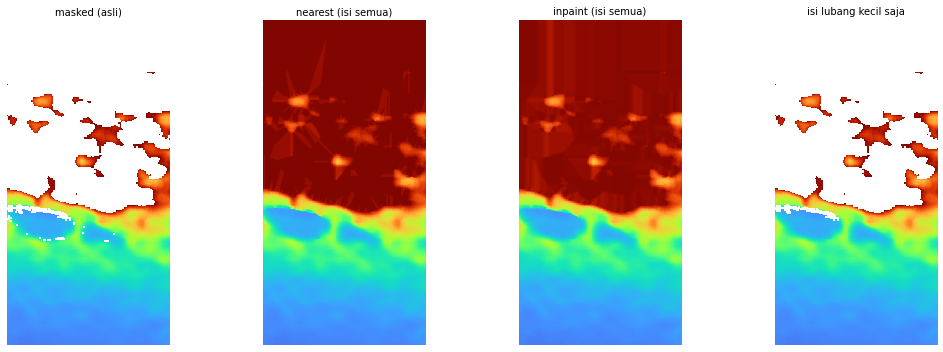

In [18]:
SCALE, DMIN, DMAX = 1/1000.0, 0.001, 20.0

def load_depth(fid, depth_dir="new_ds/Depth"):
    f = glob.glob(f"{depth_dir}/{fid}*.npy")[0]
    d = np.load(f).astype(np.float32)
    d = np.asarray(Image.fromarray(d).resize((256, 512), Image.NEAREST), dtype=np.float32) * SCALE
    valid = ((d >= DMIN) & (d < DMAX)).astype(np.uint8)
    return d, valid

def fill_nearest(d, valid):
    """isi SEMUA invalid dgn nilai valid terdekat"""
    idx = ndimage.distance_transform_edt(valid == 0, return_distances=False, return_indices=True)
    return d[tuple(idx)]

def fill_inpaint(d, valid):
    """inpaint Navier-Stokes (mulus, interpolatif)"""
    dd8 = (np.clip(d, 0, DMAX) / DMAX * 255).astype(np.uint8)
    mask = (valid == 0).astype(np.uint8) * 255
    out = cv2.inpaint(dd8, mask, 3, cv2.INPAINT_NS)
    return out.astype(np.float32) / 255.0 * DMAX

def fill_small_only(d, valid, max_hole_px=50, k=5):
    """isi HANYA lubang kecil (<max_hole_px), lubang besar dibiarkan invalid"""
    inv = (valid == 0).astype(np.uint8)
    n, lbl, stats, _ = cv2.connectedComponentsWithStats(inv, connectivity=8)
    small_mask = np.zeros_like(inv)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] < max_hole_px:
            small_mask[lbl == i] = 1
    # inpaint hanya di lubang kecil
    dd8 = (np.clip(d, 0, DMAX) / DMAX * 255).astype(np.uint8)
    filled = cv2.inpaint(dd8, (small_mask*255).astype(np.uint8), 3, cv2.INPAINT_NS)
    filled = filled.astype(np.float32) / 255.0 * DMAX
    out = np.where(small_mask > 0, filled, d)           # isi lubang kecil
    still_invalid = (valid == 0) & (small_mask == 0)    # lubang besar tetap invalid
    out[still_invalid] = np.nan
    return out

fid = "20260715_085238_120_000003"
# fid = "20260715_085238_120_000007"
# fid = "20260715_085415_150_000006"
d, valid = load_depth(fid)

methods = {
    "masked (asli)":        np.where(valid > 0, d, np.nan),
    "nearest (isi semua)":  fill_nearest(d, valid),
    "inpaint (isi semua)":  fill_inpaint(d, valid),
    "isi lubang kecil saja": fill_small_only(d, valid),
}

fig, ax = plt.subplots(1, len(methods), figsize=(15, 5))
for a, (title, arr) in zip(ax, methods.items()):
    im = a.imshow(arr, cmap="turbo", vmin=0, vmax=DMAX)
    a.set_title(title, fontsize=10); a.axis("off")
plt.tight_layout(); plt.show()

## Dataset csv

In [1]:
import numpy as np 
import pandas as pd

In [2]:
df1 = pd.read_csv('dataset.csv')
df1.columns

Index(['frame_id', 'session', 'height_cm', 'split', 'img_path', 'depth_path',
       'teacher_path', 'has_object', 'n_object', 'light', 'n_kpt_visible'],
      dtype='object')

In [3]:
df1.groupby('split')['height_cm'].count()

split
test     199
train    801
Name: height_cm, dtype: int64

In [4]:
df1.groupby('split')['height_cm'].value_counts()

split  height_cm
test   130           70
       120           67
       140           33
       150           29
train  150          176
       140          174
       160          169
       120          141
       130          141
Name: height_cm, dtype: int64

In [5]:
df1.groupby('split')['n_kpt_visible'].value_counts()

split  n_kpt_visible
test   4                105
       0                 85
       8                  9
train  4                384
       0                321
       8                 96
Name: n_kpt_visible, dtype: int64